In [1]:
import pandas as pd
from datapreparation.data_preparation import Data_Preparation as dp
prep = dp()
X = prep.prepare_data_general_v2
X

,mac_id,PumpTimeInSeconds,WaterLevel,hours_since_watering,soil_deficit_ratio,temp_deviation,air_hum_deficit,light_deviation,deficit_x_temp,deficit_x_light,deficit_x_air,et_approx
0,0,0.0,88.06,0.0,-0.002261,NaN,-0.44,106.89,NaN,-13.8957,0.0572,NaN
1,12,0.0,83.09,0.0,0.016461,-0.28,3.05,2689.33,-0.1120,1075.7320,1.2200,6572.346329
2,10,0.0,93.84,0.0,0.006767,0.65,-4.82,165.24,0.1755,44.6148,-1.3014,341.035062
3,5,0.0,82.50,0.0,0.002213,0.29,-0.17,53.53,0.0464,8.5648,-0.0272,307.328547
4,6,0.0,99.11,0.0,0.002534,NaN,-1.14,302.07,NaN,39.2691,-0.1482,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
132913,11,151.2,93.75,88.0,0.233913,-0.71,0.36,-212.05,-9.5495,-2852.0725,4.8420,457.614470
132914,1,14.5,6.00,680.0,NaN,-0.67,-0.12,-217.65,NaN,NaN,NaN,136.769313
132915,12,9.6,6.00,26.0,0.612346,NaN,0.81,-1492.69,NaN,-22211.2272,12.0528,NaN
132916,0,35.2,6.00,62.0,0.226957,0.74,NaN,-368.62,9.6570,-4810.4910,NaN,NaN


In [2]:
y = X['PumpTimeInSeconds']
X = X.drop(columns=['PumpTimeInSeconds','WaterLevel'])
y

0           0.0
1           0.0
2           0.0
3           0.0
4           0.0
          ...  
132913    151.2
132914     14.5
132915      9.6
132916     35.2
132917     38.1
Name: PumpTimeInSeconds, Length: 116801, dtype: float64

<Figure size 900x500 with 0 Axes>

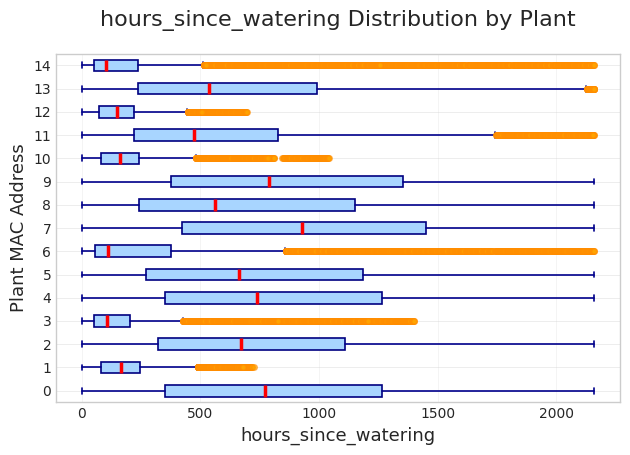

<Figure size 900x500 with 0 Axes>

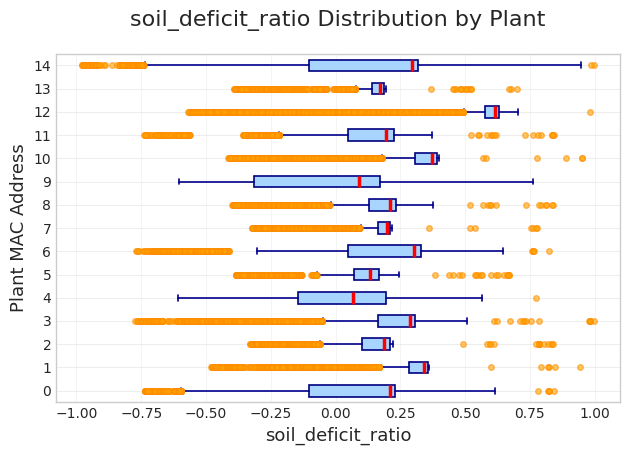

<Figure size 900x500 with 0 Axes>

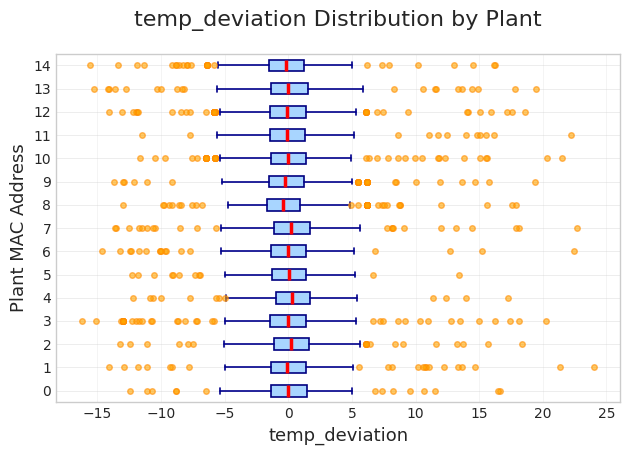

<Figure size 900x500 with 0 Axes>

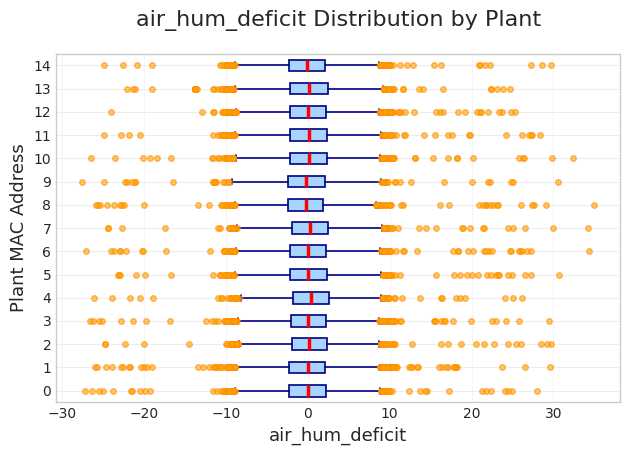

KeyboardInterrupt: 

<Figure size 900x500 with 0 Axes>

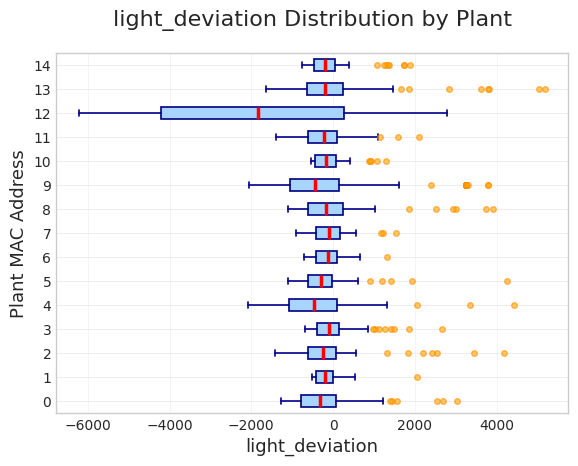

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = X.select_dtypes(include='number').columns.drop("mac_id")
plt.style.use('seaborn-v0_8-whitegrid')

for col in numeric_cols:

    plt.figure(figsize=(9, 5))

    X.boxplot(
        column=col,
        by='mac_id',
        vert=False,
        patch_artist=True,

        # Box styling
        boxprops=dict(
            facecolor='#a8d5ff',
            edgecolor='navy',
            linewidth=1.2
        ),

        # Median line
        medianprops=dict(
            color='red',
            linewidth=2.5
        ),

        # Whiskers
        whiskerprops=dict(
            color='darkblue',
            linewidth=1.2
        ),

        # Caps
        capprops=dict(
            color='darkblue',
            linewidth=1.2
        ),

        # Outliers
        flierprops=dict(
            marker='o',
            markerfacecolor='orange',
            markeredgecolor='darkorange',
            markersize=4,
            alpha=0.6
        )
    )

    plt.title(f"{col} Distribution by Plant", fontsize=16, pad=20)
    plt.suptitle("")

    plt.xlabel(col, fontsize=13)
    plt.ylabel("Plant MAC Address", fontsize=13)

    plt.xticks(rotation=0)

    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
# transform feature that are right-skewed
X["et_approx"] = X["et_approx"].apply(lambda x: np.log1p(x))

# Optional: nicer style
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure
plt.figure(figsize=(7, 5))

X.boxplot(
    column='et_approx',
    by='mac_id',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#a8d5ff', edgecolor='navy', linewidth=1.2),
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(color='darkblue'),
    capprops=dict(color='darkblue'),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.6)
)

plt.title("et_approx Distribution by Plant", fontsize=16, pad=20)
plt.suptitle("")
plt.xlabel("et_approx", fontsize=13)
plt.ylabel("Plant MAC Address", fontsize=13)


plt.xticks(rotation=0)
plt.grid(axis='x', alpha=0.3)

ax = plt.gca()
plt.tight_layout()
plt.show()

## Splitting the data

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = prep.train_val_test_split_64_16_20(func = prep.prepare_data_pump_time_v2)
X_train

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5, weights='uniform')

X_train_imputed = imputer.fit_transform(X_train)

X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

In [ ]:
X_train_imputed

## Impute the val and test data using transform

In [ ]:
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

X_val_imputed = pd.DataFrame(
    X_val_imputed,
    columns=X_val.columns,
    index=X_val.index
)
X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)
X_test_imputed

In [ ]:

from sklearn.metrics import confusion_matrix, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# correlation of each feature with target
corr_series = X_train_imputed.corrwith(y_train)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_series.to_frame(name='PumpTimeInSeconds'),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation with Pump Time')
plt.show()

In [ ]:
corr = X_train_imputed.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
## Update feature engineering to fix the 99% corr
# X_train_imputed = X_train_imputed.drop(columns=['soil_deficit'])
# X_val_imputed = X_val_imputed.drop(columns=['soil_deficit'])
# X_test_imputed = X_test_imputed.drop(columns=['soil_deficit'])


corr = X_train_imputed.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
import xgboost as xgb
import optuna


# Convert to DMatrix
dtrain = xgb.DMatrix(X_train_imputed, label=y_train)
dval = xgb.DMatrix(X_val_imputed, label=y_val)
dtest = xgb.DMatrix(X_test_imputed, label=y_test)


def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",

        # GPU
        "tree_method": "hist",
        "device": "cuda",

        # Hyperparameters
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),

        # Extra useful params
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "max_bin": trial.suggest_int("max_bin", 128, 512),

        # Optional
        "seed": 42,
    }

    cv_results = xgb.cv(
        params=params,
        dtrain=dtrain,
        num_boost_round=2000,
        nfold=3,
        early_stopping_rounds=50,
        metrics="mae",
        seed=42,
        verbose_eval=False,
    )

    best_score = cv_results["test-mae-mean"].min()

    # save best boosting round
    trial.set_user_attr("best_num_boost_round", len(cv_results))

    return best_score


# Create study
study = optuna.create_study(
    direction="minimize",
    study_name="xgb_pump_runtime"
)

# Run optimization
study.optimize(objective, n_trials=40, show_progress_bar=True)

# Best results
best_params = study.best_params
best_num_boost_round = study.best_trial.user_attrs["best_num_boost_round"]

print("\nBest Params:")
print(best_params)

print("\nBest CV MAE:")
print(study.best_value)

# Add required training params back
best_params.update({
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "tree_method": "hist",
    "device": "cuda",
    "seed": 42,
})

# Train final model
final_model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=best_num_boost_round,
    evals=[(dval, "validation")],
    verbose_eval=False
)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# evaluate
preds_val = final_model.predict(dval)
preds_test = final_model.predict(dtest)

print(f"\nBest params: {best_params}")
print(f"Best num_boost_round: {best_num_boost_round}")
print(f"\nVal  MAE: {mean_absolute_error(y_val, preds_val):.3f}")
print(f"Val  MSE: {mean_squared_error(y_val, preds_val):.3f}")
print(f"Val  R²:  {r2_score(y_val, preds_val):.4f}")
print(f"\nTest MAE: {mean_absolute_error(y_test, preds_test):.3f}")
print(f"Test MSE: {mean_squared_error(y_test, preds_test):.3f}")
print(f"Test R²:  {r2_score(y_test, preds_test):.4f}")

import os
# Delete old model before training
if os.path.exists("/workspace/models/pump-time/xgb_pump_time_regretion_model.ubj"):
    os.remove("/workspace/models/pump-time/xgb_pump_time_regretion_model.ubj")
    print("Old model deleted")

final_model.save_model("/workspace/models/pump-time/xgb_pump_time_regretion_model.ubj")
print("\nModel saved.")